In [21]:
!pip install ipympl

Defaulting to user installation because normal site-packages is not writeable


In [22]:
pip install ipympl ipywidgets


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [24]:
!pip install ipywidgets matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [25]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

In [26]:
#state defination/empty board
def initial_state():
    return np.zeros((3, 3), dtype=int)
S0= initial_state()
print(S0)

[[0 0 0]
 [0 0 0]
 [0 0 0]]


In [27]:
'''def PLAYER (board):
    x_count = np.sum(board == 1) #1 is X
    o_count = np.sum(board == -1)
    return 1 if x_count == o_count else -1
def ACTIONS (board): #legal actions, k garna paucha
    return [(r,c) for r in range (3) for c in range(3) if board [r,c] == 0]
def RESULTS (board, action): #k huncha action liye pachi
    r,c = action
    new_board = board.copy()
    new_board [r,c] = PLAYER(board)
    return new_board
def _winner (board):
    for p in [1,-1]:
        for i in range (3):
            if all (board[i,:] == p or all (board [:,i]) == p): # vertical ra horizontal ma same
                return p
            if board [0,0] == board [1,1] == board [2,2] == p: # diagonal cha ki chaina
                return p
            if board [0,2] == board [1,1] == board [2,0] == p: #diagonal cha ki chaina
                return p
            return None


def TERMINAL (board):
    return _winner(board) is not None or len (ACTIONS(board)) == 0
def UTILITY (board):
    w = _winner(board)
    return w if w is not None else 0 # since we already applied "X as 1 and "O" as -1'''

def Player(board):
    x_count = np.sum(board == 1)  # 1 is X
    o_count = np.sum(board == -1)  # -1 is O
    return 1 if x_count == o_count else -1


def ACTIONS(board):
    return [(r, c) for r in range(3) for c in range(3) if board[r, c] == 0]


def RESULT(board, action):
    r, c = action
    new_board = board.copy()
    new_board[r, c] = Player(board)
    return new_board


def _winner(board):
    for p in [1, -1]:
        for i in range(3):
            if np.all(board[i, :] == p) or np.all(board[:, i] == p):
                return p
        if board[0, 0] == board[1, 1] == board[2, 2] == p:
            return p
        if board[0, 2] == board[1, 1] == board[2, 0] == p:
            return p
    return None

In [28]:
def TERMINAL(board):
    return _winner(board) is not None or len(ACTIONS(board)) == 0


def UTILITY(board):
    w = _winner(board)
    return w if w is not None else 0  # X is 1, O is -1

In [29]:
test = np.array([[1, 1, 1],
                 [0, -1, -1],
                 [0, 0, 0]])
print("Test board:")
print(test)
print(f"  TERMINAL: {TERMINAL(test)}")
print(f"  UTILITY:  {UTILITY(test)}   <- X wins (+1)")
print(f"  PLAYER(S0): {'X' if Player(S0) == 1 else 'O'}   <- X goes first")

Test board:
[[ 1  1  1]
 [ 0 -1 -1]
 [ 0  0  0]]
  TERMINAL: True
  UTILITY:  1   <- X wins (+1)
  PLAYER(S0): X   <- X goes first


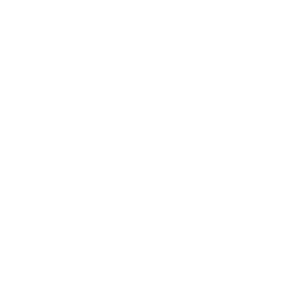

In [30]:
def draw_board(ax, board, title=""):
    ax.clear()
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor('#f7f7f7')

    # grid lines
    for i in range(1, 3):
        ax.axvline(i, color='#333333', lw=2)
        ax.axhline(i, color='#333333', lw=2)

    # pieces
    for r in range(3):
        for c in range(3):
            # board row 0 = top, but matplotlib y=0 = bottom
            # so center_y = 2.5 - r
            cx, cy = c + 0.5, 2.5 - r
            if board[r, c] == 1:   # X — blue cross
                ax.plot([cx-0.3, cx+0.3], [cy-0.3, cy+0.3], color='#2563eb', lw=4, solid_capstyle='round')
                ax.plot([cx-0.3, cx+0.3], [cy+0.3, cy-0.3], color='#2563eb', lw=4, solid_capstyle='round')
            elif board[r, c] == -1:  # O — red circle
                circ = Circle((cx, cy), 0.3, fill=False, edgecolor='#dc2626', lw=4)
                ax.add_patch(circ)

    if title:
        ax.set_title(title, fontsize=13, pad=8)


# preview empty board
fig0, ax0 = plt.subplots(figsize=(3, 3))
draw_board(ax0, S0, "S₀ — initial state")
plt.tight_layout()
plt.show()

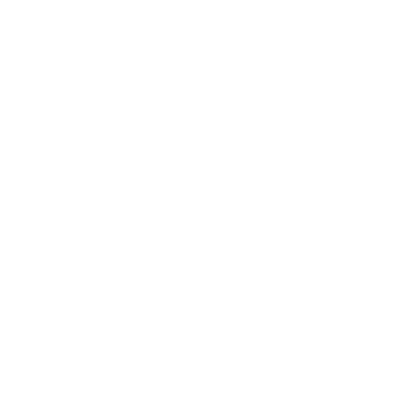

In [31]:
board_hvh = initial_state()

fig_hvh, ax_hvh = plt.subplots(figsize=(4, 4))
fig_hvh.canvas.header_visible = False
draw_board(ax_hvh, board_hvh, "Player X's turn")

def _status_hvh():
    if not TERMINAL(board_hvh):
        p = Player(board_hvh)
        return f"Player {'X' if p == 1 else 'O'}'s turn"
    u = UTILITY(board_hvh)
    if u == 1:  return "X wins!"
    if u == -1: return "O wins!"
    return "Draw!"

def onclick_hvh(event):
    global board_hvh
    if event.inaxes != ax_hvh:
        return
    if TERMINAL(board_hvh):
        return

    x, y = event.xdata, event.ydata
    if x is None or y is None:
        return
    if not (0 <= x < 3 and 0 <= y < 3):
        return

    c = int(x)
    r = 2 - int(y)  # flip: matplotlib y=0 is bottom, board row 0 is top

    if board_hvh[r, c] != 0:
        return  # cell occupied

    board_hvh = RESULT(board_hvh, (r, c))
    draw_board(ax_hvh, board_hvh, _status_hvh())
    fig_hvh.canvas.draw()

fig_hvh.canvas.mpl_connect('button_press_event', onclick_hvh)
plt.tight_layout()
plt.show()

In [ ]:
def minimax(board):
    """
    Returns (value, best_action).
    value    : +1 / 0 / -1 from current player's optimal play
    best_action: (r, c) or None on terminal
    """
    if TERMINAL(board):
        return UTILITY(board), None

    player = Player(board)

    if player == 1:  # X — Maximizer
        best_val = -float('inf')
        best_action = None
        for action in ACTIONS(board):
            val, _ = minimax(RESULT(board, action))
            if val > best_val:
                best_val, best_action = val, action
        return best_val, best_action

    else:            # O — Minimizer
        best_val = float('inf')
        best_action = None
        for action in ACTIONS(board):
            val, _ = minimax(RESULT(board, action))
            if val < best_val:
                best_val, best_action = val, action
        return best_val, best_action


val, action = minimax(S0)
print(f"From S0: best move = {action}, minimax value = {val}")
print("(value 0 → perfect play leads to draw from both sides)")